机器学习的一般过程有 数据收集->数据清洗->特征工程->模型选择->模型评估

数据收集数据清洗模型选择先略过

以下为特征工程

1.1特征选择方法

In [ ]:
import numpy as np
import pandas as pd
a = np.random.randn(100)  # 随机生产100个数据
print(np.var(a))          # 打印数据方差

0.8641293427065978


In [4]:
# import numpy as np
b=np.random.randn(100)*0.1
b=np.random.normal(5,0.1,100)  # 生产100个均值为5，标准差为0.1的随机数据
print(np.var(b))

0.005708391651433921


低方差过滤法（特征选择法之一）
对于特征的选择，可以直接基于方差来判断，这是最简单的。低方差的特征意味着该特征的所有样本值几乎相同，对预测影响极小，可以将其去掉。

In [5]:
from sklearn.feature_selection import VarianceThreshold
import numpy as np
# 构造特征向量
a = np.random.randn(100)  # 随机生产100个数据
b=np.random.normal(5,0.1,100)  # 生产100个均值为5，标准差为0.1的随机数据
x=np.vstack((a,b)).T
print(np.var(a))
# print(a)
print(np.var(b))
# print(b)
# print(x)  # 打印特征向量
print(x.shape)  # 打印特征向量的形状
vt=VarianceThreshold(threshold=0.01)  # 设置方差阈值为0.01
x_filterd=vt.fit_transform(x)  # 进行特征选择
# print(x_filterd)  # 打印选择后的特征向量
print(x_filterd.shape)  # 打印选择后的特征向量的形状

0.8195670947653595
0.013852975198387286
(100, 2)
(100, 2)


相关系数法（特征选择法之二）
通过计算特征与目标变量或特征之间的相关性，筛选出高相关性特征（与目标相关）或剔除冗余特征（特征间高度相关）。

[](./ml_img/皮尔逊.png)

In [6]:
# 皮尔逊相关系数用于衡量两个变量的线性相关性，取值范围[−1,1]。
import pandas as pd
advertising = pd.read_csv('./data/advertising.csv')  # 读取数据
# print(advertising.head())  # 打印数据的前5行
# print(advertising.shape)
# 数据预处理
#第一个参数是删除行第一个元素，第二个参数对每行做操作，第三个参数原地操作
advertising.drop(advertising.columns[0], axis=1, inplace=True)
# print(advertising.head())  # 打印数据的前5行
# 去掉空值
advertising.dropna(inplace=True)
# 取出特征和标签
X = advertising.drop('Sales', axis=1)  # 特征
y = advertising['Sales']  # 标签
# print(X.head())  # 打印特征的前5行
# print(y.head())  # 打印标签的前5行
# 计算特征与标签之间的相关系数
print(X.corrwith(y,method='pearson'))  # 打印特征与标签之间的相关系数

TV           0.782224
Radio        0.576223
Newspaper    0.228299
dtype: float64


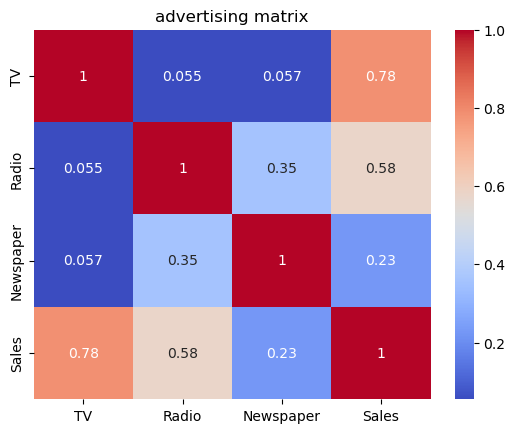

In [7]:
# 计算相关系数矩阵并画出热力图
corr_matrix = advertising.corr(method='pearson')  # 计算相关系数矩阵
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')  # 画出热力图
plt.title('advertising matrix')
plt.show()  # 显示图像

斯皮尔曼相关系数（第二种相关系数）


![](./ml_img/斯皮尔曼.png)

In [8]:
# 斯皮尔曼相关系数的应用
import pandas as pd
x = [55,65,70,75,85,50,60,72,80,58]
y = [[5],[8],[10],[12],[15],[3],[7],[9],[14],[6]]
Y = pd.DataFrame(y)
# print(y)
# print(Y)
X = pd.Series(x)
# print(x)
# print(X)
print(Y.corrwith(X,method='spearman'))  # 打印斯皮尔曼相关系数

0    0.987879
dtype: float64


1.2特征转换法

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder

np.random.seed(42)
data = np.abs(np.random.randn(6, 1) * 10) + 1  # 模拟一列正偏态数据

# ① 标准化（Z-score）：均值为0，标准差为1，适合正态分布数据
scaler_std = StandardScaler()
data_std = scaler_std.fit_transform(data)
print("原始数据:   ", data.flatten().round(2))
print("标准化结果: ", data_std.flatten().round(2))

# ② 归一化（Min-Max）：缩放到 [0, 1]，适合边界明确的特征
scaler_mm = MinMaxScaler()
data_mm = scaler_mm.fit_transform(data)
print("归一化结果: ", data_mm.flatten().round(2))

# ③ 对数变换：压缩右偏分布（如收入、销量），要求数据 > 0
data_log = np.log1p(data)  # log(1 + x) 避免 log(0)
print("对数变换结果:", data_log.flatten().round(2))

# ④ 类别编码
colors = np.array(['red', 'blue', 'green', 'blue', 'red', 'green'])
# Label Encoding：将类别映射为整数（适合有序类别或树模型）
le = LabelEncoder()
colors_le = le.fit_transform(colors)
print("\n类别标签:   ", colors)
print("Label编码:  ", colors_le)  # blue=0, green=1, red=2

# One-Hot Encoding：每个类别独立一列，避免数值大小带来的顺序假设
ohe = OneHotEncoder(sparse_output=False)
colors_ohe = ohe.fit_transform(colors.reshape(-1, 1))
print("One-Hot编码:\n", colors_ohe)

原始数据:    [ 5.97  2.38  7.48 16.23  3.34  3.34]
标准化结果:  [-0.1  -0.87  0.22  2.08 -0.66 -0.66]
归一化结果:  [0.26 0.   0.37 1.   0.07 0.07]
对数变换结果: [1.94 1.22 2.14 2.85 1.47 1.47]

类别标签:    ['red' 'blue' 'green' 'blue' 'red' 'green']
Label编码:   [2 0 1 0 2 1]
One-Hot编码:
 [[0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]]


1.3特征构造法

In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures, KBinsDiscretizer

np.random.seed(0)
df = pd.DataFrame({
    'price': np.random.randint(50, 200, 6),
    'quantity': np.random.randint(1, 20, 6),
    'age': np.random.randint(18, 60, 6),
})
print("原始特征:\n", df)

# ① 交叉特征（手动构造）：用业务逻辑组合两列，产生更有意义的新特征
df['revenue'] = df['price'] * df['quantity']  # 收入 = 单价 × 数量
df['price_per_age'] = df['price'] / df['age']  # 每岁花费（消费能力指标）
print("\n加入交叉特征:\n", df)

# ② 多项式特征（自动构造）：生成原始特征的高次项与交叉项
# degree=2 会生成 x1, x2, x1², x1*x2, x2²
X = df[['price', 'quantity']].values
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)
poly_df = pd.DataFrame(X_poly, columns=poly.get_feature_names_out(['price', 'quantity']))
print("\n多项式特征（degree=2）:\n", poly_df)

# ③ 分箱（Binning）：将连续特征离散化，捕捉非线性关系
kbd = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='quantile')
age_binned = kbd.fit_transform(df[['age']])
df['age_bin'] = age_binned.astype(int)  # 0=低龄 1=中龄 2=高龄
print("\n年龄分箱结果:\n", df[['age', 'age_bin']])

原始特征:
    price  quantity  age
0     97        19   57
1    167         5   41
2    117         7   42
3    153        13   35
4     59         2   55
5     71         7   43

加入交叉特征:
    price  quantity  age  revenue  price_per_age
0     97        19   57     1843       1.701754
1    167         5   41      835       4.073171
2    117         7   42      819       2.785714
3    153        13   35     1989       4.371429
4     59         2   55      118       1.072727
5     71         7   43      497       1.651163

多项式特征（degree=2）:
    price  quantity  price^2  price quantity  quantity^2
0   97.0      19.0   9409.0          1843.0       361.0
1  167.0       5.0  27889.0           835.0        25.0
2  117.0       7.0  13689.0           819.0        49.0
3  153.0      13.0  23409.0          1989.0       169.0
4   59.0       2.0   3481.0           118.0         4.0
5   71.0       7.0   5041.0           497.0        49.0

年龄分箱结果:
    age  age_bin
0   57        2
1   41        0
2   42    

1.4pca特征降维

主成分分析（PCA）
是一种常用的降维技术，通过线性变换将高维数据投影到低维空间，同时保留数据的主要变化模式。

使用sklearn.decomposition.PCA进行主成分分析。参数n_components若为小数则表示保留多少比例的信息，为整数则表示保留多少个维度。

(1000, 2)


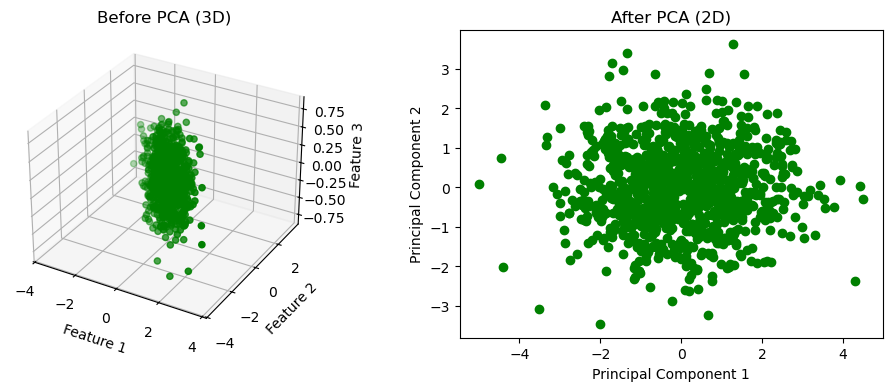

In [11]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
num_number = 1000 #每组特征生产数量
col1 = np.random.normal(loc=0, scale=1, size=num_number)  # 生产1000个均值为0，标准差为1的随机数据
col2 = np.random.normal(loc=0, scale=0.2, size=num_number)  # 生产1000个均值为0，标准差为0.1的随机数据
noise = np.random.normal(loc=0, scale=0.1, size=num_number)  # 生产1000个均值为0，标准差为1的随机数据,作为噪声
X = np.vstack([col1+col2,col2-col1,col2+noise]).T  # 将三列特征组合成一个特征矩阵
# 标准化
scaler = StandardScaler()
X_standardized = scaler.fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_standardized)
print(X_pca.shape)  # 打印降维后的特征矩阵的形状
# 可视化
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(12, 4))
ax1 = fig.add_subplot(121, projection="3d")
#print(X.shape)# 打印原始特征矩阵的形状
ax1.scatter(X[:, 0], X[:, 1], X[:,2], c="g")
ax1.set_title("Before PCA (3D)")
ax1.set_xlabel("Feature 1")
ax1.set_ylabel("Feature 2")
ax1.set_zlabel("Feature 3")
# 转换后的2维数据可视化
ax2 = fig.add_subplot(122)
ax2.scatter(X_pca[:, 0], X_pca[:, 1], c="g")
ax2.set_title("After PCA (2D)")
ax2.set_xlabel("Principal Component 1")
ax2.set_ylabel("Principal Component 2")
plt.show()

损失函数用来判断预测结果和真实结果的偏差
损失函数本质是模型参数的函数

![](./ml_img/损失函数1.png)
![](./ml_img/损失函数2.png)